# SPY-asian-pricer — Demo

Arithmetic-average **Asian options on SPY** under **Dupire local volatility**, calibrated from the live Yahoo Finance option chain.

```
Yahoo chain  →  bid/ask mid + quote-quality filter  →  per-slice SVI fit + butterfly gate
              →  JWSVI surface  ┐
                                 ├──→  Dupire local vol  →  Asian MC (antithetic)  →  price + Greeks
              →  SSVI surface   ┘
```

**From raw quotes to a parametric vol surface**.  The Yahoo chain gives us a discrete cloud of points $(K_i, T_j, \sigma_{\rm iv}^{ij})$ — implied vols at the strikes that traded, on the expiries Yahoo lists, with everything in between *missing*.  To run Dupire (which needs $\partial_T w$ and $\partial_{KK} C$ everywhere) and to do path-dependent MC, we have to fit a smooth, arbitrage-aware function $w(K, T) = \sigma_{\rm iv}^2(K, T) \cdot T$ through that cloud.  This is what SVI / JWSVI / SSVI do — they are three increasingly-constrained parameterisations of the *same* implied total-variance surface.

**Two surfaces in parallel**:

- **SVI (Gatheral 2004) — the building block, per-expiry**.  At a fixed maturity $T$, the smile is parameterised in $y = \ln(K/F)$ by 5 numbers $(a, b, \rho, m, \sigma)$:

  $$w(y) \;=\; a + b\,\Bigl(\rho\,(y - m) + \sqrt{(y - m)^2 + \sigma^2}\Bigr)$$

  Level, slope, asymmetry, horizontal shift, convexity.  Fits real equity-index smiles to within a few bps and gives **closed-form $w', w''$** — exactly what the Dupire denominator needs.  Independent SVI fits *do not talk to each other across tenors*; calendar arbitrage is a post-hoc check.

- **JWSVI (Gatheral & Jacquier 2014) — same SVI, financially-meaningful coordinates**.  Raw $(a, b, \rho, m, \sigma)$ have no direct financial interpretation, so interpolating them in $T$ is unstable.  Jump-Wing reparameterises the same 5-param SVI slice as 6 quantities a trader can read off a smile chart:  ATM variance $\nu$, ATM skew $\phi$, put-wing slope $p$, call-wing slope $c$, minimum variance $\tilde\nu$, convexity.  Time-interpolating these (linear or cubic in $T$) gives a smooth surface; per-slice flexibility is preserved (each expiry can capture its own quirk), and **vega-bucket attribution is natural** since each tenor moves independently.  This is what most sell-side desks run — they get away with calendar arb being post-hoc because Bloomberg-quality data + trader override make it rare.

- **SSVI (Gatheral 2014) — joint, surface-level**.  Three global parameters describe the *shape* of every smile across the entire surface, and only the ATM total variance $\theta(t)$ varies tenor-by-tenor:

  $$w(k, t) \;=\; \tfrac{\theta(t)}{2}\,\Bigl(1 + \rho\,\phi(\theta) k + \sqrt{(\phi(\theta) k + \rho)^2 + 1 - \rho^2}\Bigr), \quad \phi(\theta) = \eta\,\theta^{-\gamma}$$

  Total params: $3 + N$ instead of $5 \times N$.  **Calendar-arbitrage-free by construction** when $\theta$ is monotone and $\gamma \in [0, 1/2]$ (both enforced by the calibrator).  At each fixed tenor SSVI reduces in *closed form* to a raw SVI slice, so it plugs into the same `DupireLocalVol` machinery as JWSVI — the only difference is upstream of `get_svi_at(dcf)`.


In [1]:
!pip install -U "spy-asian-pricer[data,plot]" --quiet


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from spy_asian_pricer import (
    calibrate_svi, JWSVIVolSurface, DupireLocalVol, AsianMCPricer,
    compute_greeks,
    check_butterfly_arbitrage, check_calendar_arbitrage, check_spread_arbitrage,
    filter_butterfly_arbitrage,
    fetch_spot, fetch_dividend_yield, fetch_risk_free_rate, build_vol_grid,
    SSVISurface, calibrate_ssvi,
)

np.random.seed(42)


## 1. Calibrate two surfaces from the same data

`build_vol_grid` (full filter spec in README §1):

- OTM puts/calls only; **IV reverse-implied from bid/ask mid** (with `lastPrice` fallback off-hours), Yahoo's broken IV column discarded
- Quote-quality gate: $\mathrm{bid}>0$, $\mathrm{ask}>\mathrm{bid}$, $(\mathrm{ask}-\mathrm{bid})/\mathrm{mid}<50\%$, plus $\mathrm{vol}>0$ or $\mathrm{OI}>0$
- Tenor band `[14d, 2y]` — Yahoo-clean preset (drops noisy weeklies + stale LEAPS)

**Pre-cleaning** drops slices whose Gatheral $g_{\min}<-0.05$ — catastrophic per-slice fits where the implied PDF goes deeply negative.  Both JWSVI and SSVI calibrate on the *same* cleaned set so the comparison is apples-to-apples.


### Why SPY?

SPY is uniquely well-suited for this fully-automated, retail-data pipeline:

- **Liquidity**: the most-traded equity options market in the world (~3M contracts/day), with tight bid-ask, hundreds of strikes per expiry, and minute-fresh `lastPrice` even on Yahoo.
- **Smooth smile**: a basket of 500 stocks averages away idiosyncratic noise, so the empirical IV surface is statistically smooth — exactly the regime where SVI's parametric form fits well.
- **No event risk**: no earnings, no M&A, no dividend surprises beyond a small continuous yield. Each expiry's smile reflects pure index-level vol pricing, not company-specific shocks.

Run the same code on a single name like **TSLA** and you'll see catastrophic per-slice SVI fits ($g_{\min} \ll -10$), >50% butterfly failures, and unstable surfaces — single stocks need Bloomberg-quality bid/ask + trader mark-overrides, neither of which a free-data demo can provide. **SPY is "easy mode" where the methodology is what's being tested, not the data quality.**

In [3]:
spot = fetch_spot('SPY')
q    = fetch_dividend_yield('SPY')
r    = fetch_risk_free_rate(tenor_years=0.5)
# Yahoo ^IRX (13-week T-bill) is the standard short-end proxy.  For longer
# Asian tenors pass tenor_years to interpolate up the Treasury curve.
print(f'Spot ${spot:.2f}  |  r={r:.2%}  |  q={q:.2%}  '
      f'->  fwd(1y) = ${spot * np.exp((r-q)):.2f}')
# Tenor band defaults to [2d, 7y] (industry-standard 7y cutoff).  Tighten
# to [14d, 2y] here as a Yahoo-clean preset:
#   - drops 0DTE / 1DTE weeklies (very noisy reverse-implied IV)
#   - drops LEAPS > 2y (Yahoo lastPrice can be days/weeks stale)
# This vol_data is then cleaned ONCE (below) and the resulting slice set
# is fed to BOTH JWSVI and SSVI so the comparison is apples-to-apples.
vol_data = build_vol_grid('SPY', spot=spot, r=r, q=q,
                          min_dte=14, max_dte=365 * 2)
print(f'\n{len(vol_data)} expiry slices after upstream filters '
      f'(bid/ask quality, vol/OI, moneyness band)')

# ── Pre-clean: per-slice SVI fit (also feeds JWSVI) + butterfly-arb gate ──
svi_slices_raw = {
    exp: (calibrate_svi(df['logMoneyness'].values,
                        df['impliedVolatility'].values,
                        df['dcf'].iloc[0]),
          df['dcf'].iloc[0])
    for exp, df in vol_data.items()
}
print('\nButterfly-arb gate (drop slices with g_min < -0.05):')
svi_slices, dropped = filter_butterfly_arbitrage(svi_slices_raw, threshold=-0.05)
vol_data_clean = {k: vol_data[k] for k in svi_slices}
print(f'  -> {len(vol_data_clean)} slices kept; both surfaces calibrate on this set.')

# ── (A) JWSVI from surviving per-slice SVI fits ──
jwsvi_slices = {k: (svi.to_jwsvi(dcf), dcf) for k, (svi, dcf) in svi_slices.items()}
jwsvi_surface = JWSVIVolSurface(jwsvi_slices, spot=spot, r=r, q=q)
jwsvi_lv = DupireLocalVol(jwsvi_surface)

# ── (B) SSVI joint global calibration on the same set ──
print()
ssvi_surface = calibrate_ssvi(vol_data_clean, spot=spot, r=r, q=q, mode='full')
ssvi_lv = DupireLocalVol(ssvi_surface)

# Side-by-side Dupire clamp diagnostics
print(f'\n{"Dupire safety clamps":<22s} {"JWSVI":>10s} {"SSVI":>10s}')
print('-' * 44)
for k in ('dwdt_floor_pct', 'denom1_floor_pct', 'density_cap_pct', 'lv_cap_pct'):
    print(f'  {k:<20s} {jwsvi_lv.clamp_stats[k]:>9.2f}% {ssvi_lv.clamp_stats[k]:>9.2f}%')


Spot $715.17  |  r=3.61%  |  q=1.14%  ->  fwd(1y) = $733.05

21 expiry slices after upstream filters (bid/ask quality, vol/OI, moneyness band)

Butterfly-arb gate (drop slices with g_min < -0.05):
  DROP 2026-08-31 (dcf=0.3425): g_min=-9.229e-02, n_viol=31
filter_butterfly_arbitrage(threshold=-0.05): kept 20/21 slices, dropped 1.
  -> 20 slices kept; both surfaces calibrate on this set.

SSVI calibration (mode='full'):
  eta   = 1.0116   (skew curvature scale)
  rho   = -0.6412   (spot-vol correlation, equity skew is negative)
  gamma = 0.4990   (term-structure decay, in [0, 0.5])
  fit    weighted SS = 3.1446e-03, n_obs = 2566, rmse(w) = 1.1070e-03
  theta(t): 20 knots, monotone-by-construction

Dupire safety clamps        JWSVI       SSVI
--------------------------------------------
  dwdt_floor_pct           26.36%      0.00%
  denom1_floor_pct         12.40%      0.00%
  density_cap_pct           3.75%      0.00%
  lv_cap_pct                2.47%      0.00%


**Reading the diagnostics**:

- **Slices kept** — outliers with $g_{\min}\ll 0$ get dropped (the trader-style cleanup automated).
- **SSVI globals**: equity $\rho$ should be negative (leverage effect); $\gamma\to 0.5$ hitting the upper bound signals noisy short end pulling the joint fit.
- **Dupire safety clamps** — counts of $(T, K)$ grid cells where the local-vol formula would have produced something un-physical:

| Clamp | What fires it |
|---|---|
| `dwdt_floor_pct` | $\partial_T w<0$ → **calendar arb** in the surface |
| `denom1_floor_pct` | Gatheral denom collapse (wing extrapolation unreliable) |
| `density_cap_pct` | Local **butterfly arb** — fitted PDF goes negative |
| `lv_cap_pct` | $\sigma_{\rm loc}>10\sigma_{\rm ATM}$ blow-up |

SSVI's structural calendar-arb-free guarantee shows up as $\sim 0\%$ across the board; JWSVI's per-slice independence routinely leaks 20–30% on noisy data.  This gap is the cleanest single signal that one surface is structurally cleaner than the other.


### Math sidebar — from implied vol to local vol (Dupire)

Both calibrators give us **implied vol** $\sigma_{\rm iv}(K, T)$, the static price grid.  To price a path-dependent product like an Asian we need **dynamics** for spot.

**Dupire (1994)**: there is a unique deterministic local volatility $\sigma_{\rm loc}(S, t)$ such that

$$dS_t \;=\; (r - q)\,S_t\,dt \;+\; \sigma_{\rm loc}(S_t, t)\,S_t\,dW_t$$

reproduces *every* observed European call price.  In total-variance form:

$$\boxed{\;\sigma_{\rm loc}^2(K, T) \;=\; \dfrac{\partial_T w(K, T)}{g(K, T)}\;}$$

where $w = \sigma_{\rm iv}^2 T$ and $g$ is **Gatheral's denominator**:

$$g(K, T) \;=\; \Bigl(1 - \tfrac{y\,w'}{2w}\Bigr)^{2} - \tfrac{(w')^2}{4}\Bigl(\tfrac{1}{w} + \tfrac{1}{4}\Bigr) + \tfrac{w''}{2}, \quad y = \ln(K/F)$$

**The same $g$ that governs butterfly arbitrage (PDF positivity) is the local-vol denominator** — internal arbitrage in the IV surface manifests as pathology in the local vol surface.  This is exactly why the §1 clamp counts work as a diagnostic.

`DupireLocalVol` implements: (1) cubic spline $w(K, \cdot)$ in $T$ → analytic $\partial_T w$, (2) closed-form $w', w''$ from each surface's SVI, (3) the four safety clamps reported above, (4) `RectBivariateSpline` for $O(1)$ MC sampling.


## 2. Visualise both surfaces

Four side-by-side views:

1. **Smile overlay** at three tenors — local fit-shape comparison
2. **ATM IV term structure** — direct view of $\theta(t)$
3. **3D implied-vol surface** — full $(K, T, \sigma_{\rm iv})$
4. **3D Dupire local-vol surface** — what the MC engine actually samples; smoothness here = pricing reliability


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10769/3982920564.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('log-moneyness $y = \ln(K/F)$')


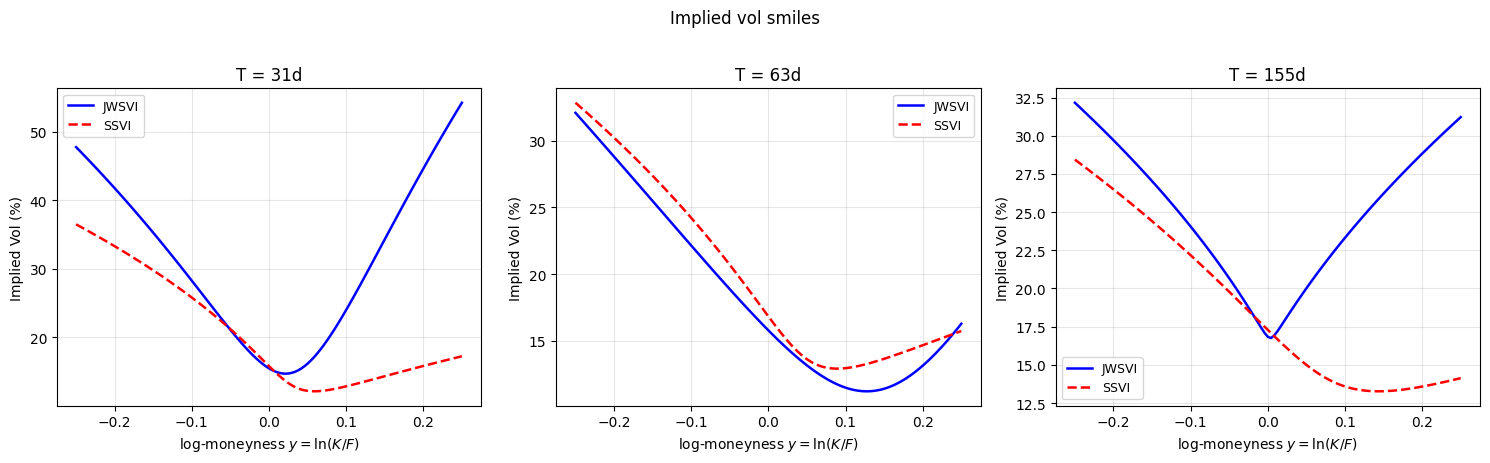

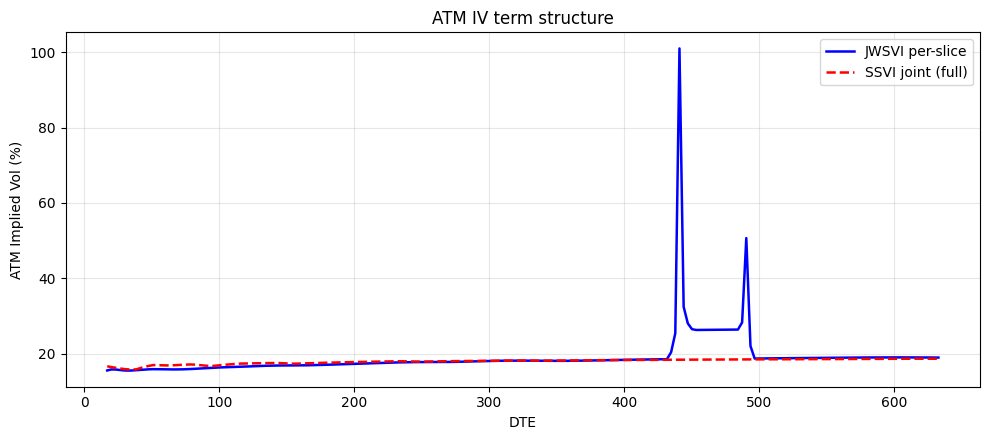

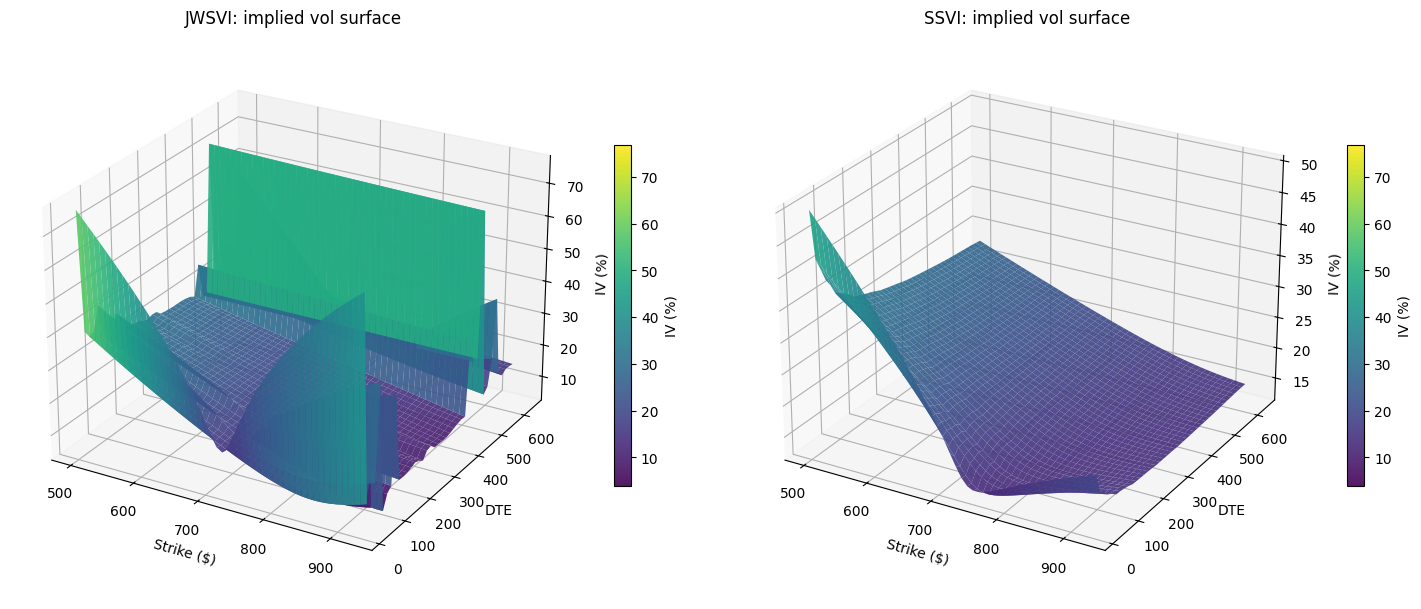

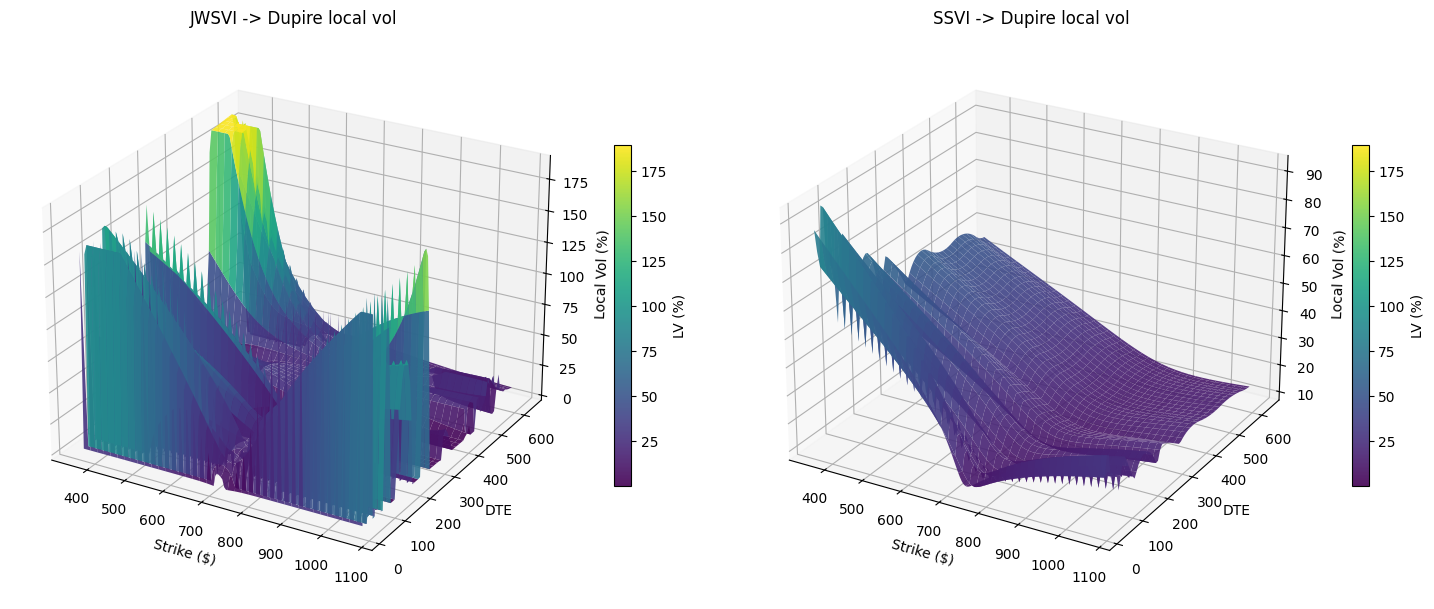

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers projection='3d')

# ── (1) Smile overlay at three representative tenors ──
n_dcf = len(jwsvi_surface.dcfs)
target_dcfs = [jwsvi_surface.dcfs[n_dcf // 8],
               jwsvi_surface.dcfs[n_dcf // 4],
               jwsvi_surface.dcfs[n_dcf // 2]]
y_grid = np.linspace(-0.25, 0.25, 121)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t_q in zip(axes, target_dcfs):
    fwd = spot * np.exp((r - q) * t_q)
    K_grid = fwd * np.exp(y_grid)
    iv_jw   = jwsvi_surface.implied_vol(K_grid, t_q) * 100
    iv_ssvi = ssvi_surface.implied_vol(K_grid, t_q) * 100
    ax.plot(y_grid, iv_jw,   'b-',  lw=1.8, label='JWSVI')
    ax.plot(y_grid, iv_ssvi, 'r--', lw=1.8, label='SSVI')
    ax.set_xlabel('log-moneyness $y = \ln(K/F)$')
    ax.set_ylabel('Implied Vol (%)')
    ax.set_title(f'T = {t_q*365:.0f}d')
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.suptitle('Implied vol smiles', y=1.02)
plt.tight_layout(); plt.show()


# ── (2) ATM IV term structure overlay ──
dcf_plot = np.linspace(jwsvi_surface.dcfs[0], jwsvi_surface.dcfs[-1], 200)
atm_jw   = np.array([jwsvi_surface.implied_vol(np.array([spot*np.exp((r-q)*d)]), d)[0]
                     for d in dcf_plot])
atm_ssvi = np.array([ssvi_surface.implied_vol (np.array([spot*np.exp((r-q)*d)]), d)[0]
                     for d in dcf_plot])
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dcf_plot * 365, atm_jw   * 100, 'b-',  lw=1.8, label='JWSVI per-slice')
ax.plot(dcf_plot * 365, atm_ssvi * 100, 'r--', lw=1.8, label='SSVI joint (full)')
ax.set_xlabel('DTE'); ax.set_ylabel('ATM Implied Vol (%)')
ax.set_title('ATM IV term structure')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


# ── (3) 3D Implied-Vol surface (JWSVI + SSVI side by side) ──
K_iv   = np.linspace(spot * 0.7, spot * 1.3, 50)
dcf_iv = np.linspace(jwsvi_surface.dcfs[0], jwsvi_surface.dcfs[-1], 40)
K_mesh, T_mesh = np.meshgrid(K_iv, dcf_iv)
iv_jw_3d   = jwsvi_surface.implied_vol_grid(K_iv, dcf_iv) * 100
iv_ssvi_3d = ssvi_surface .implied_vol_grid(K_iv, dcf_iv) * 100
zmax = max(np.nanmax(iv_jw_3d), np.nanmax(iv_ssvi_3d))
zmin = min(np.nanmin(iv_jw_3d), np.nanmin(iv_ssvi_3d))

fig = plt.figure(figsize=(15, 6))
for i, (Z, title) in enumerate([(iv_jw_3d,   'JWSVI: implied vol surface'),
                                 (iv_ssvi_3d, 'SSVI: implied vol surface')], 1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    surf = ax.plot_surface(K_mesh, T_mesh * 365, Z,
                            cmap='viridis', alpha=0.9, edgecolor='none',
                            vmin=zmin, vmax=zmax)
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('DTE'); ax.set_zlabel('IV (%)')
    ax.set_title(title)
    ax.view_init(elev=25, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.6, label='IV (%)')
plt.tight_layout(); plt.show()


# ── (4) 3D Dupire Local-Vol surface (JWSVI + SSVI side by side) ──
fig = plt.figure(figsize=(15, 6))
lv_data = [(jwsvi_lv, 'JWSVI -> Dupire local vol'),
           (ssvi_lv,  'SSVI -> Dupire local vol')]
zmax_lv = max(np.nanmax(lv.lv_grid_data) for lv, _ in lv_data) * 100
zmin_lv = min(np.nanmin(lv.lv_grid_data) for lv, _ in lv_data) * 100

for i, (lv, title) in enumerate(lv_data, 1):
    K_mesh_lv, T_mesh_lv = np.meshgrid(lv.K_grid, lv.dcf_grid * 365)
    ax = fig.add_subplot(1, 2, i, projection='3d')
    surf = ax.plot_surface(K_mesh_lv, T_mesh_lv, lv.lv_grid_data * 100,
                            cmap='viridis', alpha=0.9, edgecolor='none',
                            rstride=2, cstride=4,
                            vmin=zmin_lv, vmax=zmax_lv)
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('DTE'); ax.set_zlabel('Local Vol (%)')
    ax.set_title(title)
    ax.view_init(elev=25, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.6, label='LV (%)')
plt.tight_layout(); plt.show()


## 3. Static arbitrage diagnostics

A surface that violates static arbitrage allows model-free profit from the option prices it generates — pricing on top of it is meaningless.  Three classical conditions:

- **Butterfly** — $g(y) \ge 0$ per slice (implied PDF non-negative)
- **Calendar** — $w(K, T)$ non-decreasing in $T$ (variance only accumulates)
- **Spread** — call-price slope $\ge -e^{-rT}$ (no two-call portfolio dominates a third)

JWSVI's per-slice independence makes calendar arb between adjacent slices common on noisy data.  SSVI is **calendar-arb-free by construction**.


In [5]:
K_chk = np.linspace(spot * 0.8, spot * 1.2, 80)

print(f'{"Check":<28s} {"JWSVI":>16s} {"SSVI":>16s}')
print('-' * 64)

# 1. Calendar
jw_ok, jw_n, _ = check_calendar_arbitrage(jwsvi_surface, K_chk)
ss_ok, ss_n, _ = check_calendar_arbitrage(ssvi_surface,  K_chk)
print(f'{"Calendar arbitrage":<28s} '
      f'{("PASS" if jw_ok else f"{jw_n} viol."):>16s} '
      f'{("PASS" if ss_ok else f"{ss_n} viol."):>16s}')

# 2. Per-slice butterfly
def _butterfly_summary(surf):
    n_fail = 0
    for d in surf.dcfs:
        ok, _, _ = check_butterfly_arbitrage(surf.get_svi_at(d), d)
        if not ok: n_fail += 1
    return n_fail, len(surf.dcfs)

jw_bf, jw_t = _butterfly_summary(jwsvi_surface)
ss_bf, ss_t = _butterfly_summary(ssvi_surface)
print(f'{"Butterfly (slices failing)":<28s} '
      f'{f"{jw_bf}/{jw_t}":>16s} '
      f'{f"{ss_bf}/{ss_t}":>16s}')

# 3. Spread arb at the mid-tenor (representative)
T_chk = jwsvi_surface.dcfs[len(jwsvi_surface.dcfs) // 2]
jw_sp_ok, jw_sp_n, _ = check_spread_arbitrage(jwsvi_surface, T_chk, K_chk, r=r)
ss_sp_ok, ss_sp_n, _ = check_spread_arbitrage(ssvi_surface,  T_chk, K_chk, r=r)
print(f'{"Spread @ mid-tenor":<28s} '
      f'{("PASS" if jw_sp_ok else f"{jw_sp_n} viol."):>16s} '
      f'{("PASS" if ss_sp_ok else f"{ss_sp_n} viol."):>16s}')


Check                                   JWSVI             SSVI
----------------------------------------------------------------
Calendar arbitrage                  380 viol.             PASS
Butterfly (slices failing)               4/20             0/20
Spread @ mid-tenor                       PASS             PASS


## 4. Price the same Asian under both surfaces

### What we are pricing

6-month at-the-money **arithmetic Asian call**, daily averaging:

$$C \;=\; e^{-rT}\,\mathbb{E}\!\Bigl[\max\bigl(\bar{A} - K,\;0\bigr)\Bigr], \qquad \bar{A} = \tfrac{1}{N}\sum_{i=1}^{N} S_{t_i}, \quad N=126,\; T=0.5$$

The arithmetic average has **no closed form** even under GBM (sum of lognormals isn't lognormal), so MC is mandatory.

### Path simulation: Euler–Maruyama on log-price

For each path we discretize the local-vol SDE in log-space:

$$\log S_{t + \Delta t} \;=\; \log S_t \;+\; \Bigl(r - q - \tfrac{1}{2}\sigma_{\rm loc}^2\Bigr)\Delta t \;+\; \sigma_{\rm loc}\sqrt{\Delta t}\,Z, \qquad Z\sim\mathcal{N}(0,1)$$

Two implementation details: $\sigma_{\rm loc}$ is sampled at the **midpoint** $t + \Delta t/2$ (one order better weak error), and the averaging grid (`n_obs`) is **decoupled** from the Euler grid (`n_obs × n_steps_per_obs`) so coarse averaging keeps a fine simulation step.

### Antithetic variates: variance reduction for free

Plain MC has SE $= \sigma/\sqrt{N}$ where $\sigma^2 = \mathrm{Var}(f(Z))$ and $f$ is the discounted payoff.  Pair every Brownian draw $Z$ with its mirror $-Z$ and average:

$$\hat{C}_{\rm anti} \;=\; \frac{1}{N}\sum_{i=1}^{N/2}\frac{f(Z_i) + f(-Z_i)}{2}, \qquad \mathrm{Var}(\hat{C}_{\rm anti}) \;=\; \frac{1}{2N}\Bigl[\sigma^2 + \mathrm{Cov}\bigl(f(Z), f(-Z)\bigr)\Bigr]$$

So antithetic helps **iff $f(Z)$ and $f(-Z)$ are negatively correlated** — i.e. up-moves and down-moves give meaningfully different payoffs.  ATM Asians sit comfortably in this regime ($\rho\sim-0.6$ on SPY 6M) → SE drops 30–50% of variance if LV surface is smooth.  Clamped LV ($f(Z)$ no longer smooth function) or Deep OTM payoffs *can* break antithetic (both pair members return zero most of the time → positive correlation).



In [6]:
T       = 0.5
n_obs   = 126
K       = spot
n_paths = 200_000

def _price_under(surf, lv, label):
    pricer = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                           vol_surface=surf, local_vol_surface=lv)
    np.random.seed(42)
    res = pricer.price_asian(K, n_paths)            # antithetic=True by default
    print(f'  {label:<20s} ${res["price"]:9.4f}  +/- ${res["std_err"]:.4f}  '
          f'95% CI [${res["ci_95"][0]:.4f}, ${res["ci_95"][1]:.4f}]')
    return res, pricer

print(f'ATM 6M Asian call (n_paths={n_paths:,}):')
res_jw,   pr_jw   = _price_under(jwsvi_surface, jwsvi_lv, 'JWSVI per-slice')
res_ssvi, pr_ssvi = _price_under(ssvi_surface,  ssvi_lv,  'SSVI joint (full)')
diff = res_ssvi['price'] - res_jw['price']
print(f'\n  diff (SSVI - JWSVI) = ${diff:+.4f}  '
      f'({diff / res_jw["price"] * 100:+.2f}% of JWSVI)')


# ── Antithetic variance reduction (vs plain MC at same n_paths) ──
print(f'\nAntithetic variance reduction (same n_paths={n_paths:,}):')
print(f'  {"":<20s} {"SE plain":>10s}  {"SE antithetic":>13s}  '
      f'{"Var reduction":>14s}  {"SE reduction":>13s}')
print('  ' + '-' * 76)
for pricer, label, res_anti in [(pr_jw,   'JWSVI', res_jw),
                                 (pr_ssvi, 'SSVI',  res_ssvi)]:
    np.random.seed(42)
    res_plain = pricer.price_asian(K, n_paths, antithetic=False)
    se_p, se_a = res_plain['std_err'], res_anti['std_err']
    print(f'  {label:<20s} ${se_p:>8.4f}  ${se_a:>12.4f}  '
          f'{(se_p/se_a)**2:>13.2f}x  {se_p/se_a:>12.2f}x')

ATM 6M Asian call (n_paths=200,000):
  JWSVI per-slice      $  21.3168  +/- $0.0792  95% CI [$21.1616, $21.4719]
  SSVI joint (full)    $  22.3997  +/- $0.0300  95% CI [$22.3409, $22.4584]

  diff (SSVI - JWSVI) = $+1.0829  (+5.08% of JWSVI)

Antithetic variance reduction (same n_paths=200,000):
                         SE plain  SE antithetic   Var reduction   SE reduction
  ----------------------------------------------------------------------------
  JWSVI                $  0.0920  $      0.0792           1.35x          1.16x
  SSVI                 $  0.0558  $      0.0300           3.47x          1.86x


## 5. Greeks (call & put, common random numbers)

Central FD with `seed=42` reset before every bump → MC noise cancels exactly between $S \pm \delta S$ pairs.  Bumps: $\pm 1\%$ spot ($\Delta, \Gamma$), $\pm 1$ vol pt absolute parallel shift on diffusion ($\nu$), $-1$ day ($\Theta$).

European put-call parity $\Delta_C - \Delta_P = e^{-qT}$ is *approximate* for Asians (averaging breaks the European identity by a small amount).  Sanity check on the put pipeline.


In [7]:
def _greeks_under(surf, lv, call=True):
    return compute_greeks(spot, K, r, T, n_obs, surf, lv,
                          n_paths=120_000, call=call)

g_jw_call  = _greeks_under(jwsvi_surface, jwsvi_lv, call=True)
g_jw_put   = _greeks_under(jwsvi_surface, jwsvi_lv, call=False)
g_ss_call  = _greeks_under(ssvi_surface,  ssvi_lv,  call=True)
g_ss_put   = _greeks_under(ssvi_surface,  ssvi_lv,  call=False)

print(f'{"Greek":<8s} {"JWSVI Call":>12s} {"JWSVI Put":>12s} {"SSVI Call":>12s} {"SSVI Put":>12s}')
print('-' * 60)
for k in ('price', 'delta', 'gamma', 'vega', 'theta'):
    print(f'{k:<8s} {g_jw_call[k]:>12.4f} {g_jw_put[k]:>12.4f} '
          f'{g_ss_call[k]:>12.4f} {g_ss_put[k]:>12.4f}')

# Put-call parity sanity (European: delta_call - delta_put = exp(-q*T))
print(f'\nDelta parity exp(-q*T) = {np.exp(-q*T):.4f}')
print(f'  JWSVI: delta_call - delta_put = {g_jw_call["delta"] - g_jw_put["delta"]:+.4f}')
print(f'  SSVI : delta_call - delta_put = {g_ss_call["delta"] - g_ss_put["delta"]:+.4f}')
print('  (Asian only approximately satisfies European parity due to averaging.)')


Greek      JWSVI Call    JWSVI Put    SSVI Call     SSVI Put
------------------------------------------------------------
price         21.2555      16.8896      22.3862      17.9865
delta          0.4622      -0.5239       0.4109      -0.5776
gamma          0.0027       0.0034       0.0086       0.0086
vega           1.2129       1.2094       1.2177       1.2179
theta         -0.0977      -0.0808      -0.0743      -0.0505

Delta parity exp(-q*T) = 0.9943
  JWSVI: delta_call - delta_put = +0.9861
  SSVI : delta_call - delta_put = +0.9885
  (Asian only approximately satisfies European parity due to averaging.)


## 6. Model risk — tenor band sensitivity

`[min_dte, max_dte]` is upstream of every other knob in the pipeline.  Sweep three bands:

- **`[7d, 2y]`** — wide, includes noisy 1-week weeklies
- **`[14d, 2y]`** — base case (used in §1–§5)
- **`[28d, 2y]`** — tighter case

**Expected pattern**: noisy short-end pollutes both surfaces but in *opposite* directions.  JWSVI per-slice cubic-T overshoots → biased **high**.  SSVI joint optimisation absorbs noise into $\theta(t)$ but the monotone constraint forces it **low**.  When the two methods agree, the data is clean enough; when they don't, neither price is trustworthy on its own.


Running [7d, 2y]   (wide, includes weeklies)...
Running [14d, 2y]  (base case — used in §1-§6)...
Running [28d, 2y]  (tighter case)...

Tenor band                                slices   JW price     JW SE  SSVI price   SSVI SE     diff  JW calArb  SSVI calArb
----------------------------------------------------------------------------------------------------------------------------
[7d, 2y]   (wide, includes weeklies)          22 $    24.73 $  0.1657 $     27.46 $  0.0587 $  +2.73        380            0
[14d, 2y]  (base case — used in §1-§6)        20 $    21.29 $  0.1104 $     22.41 $  0.0423 $  +1.13        380            0
[28d, 2y]  (tighter case)                     18 $    21.33 $  0.1290 $     21.85 $  0.0411 $  +0.52        309            0


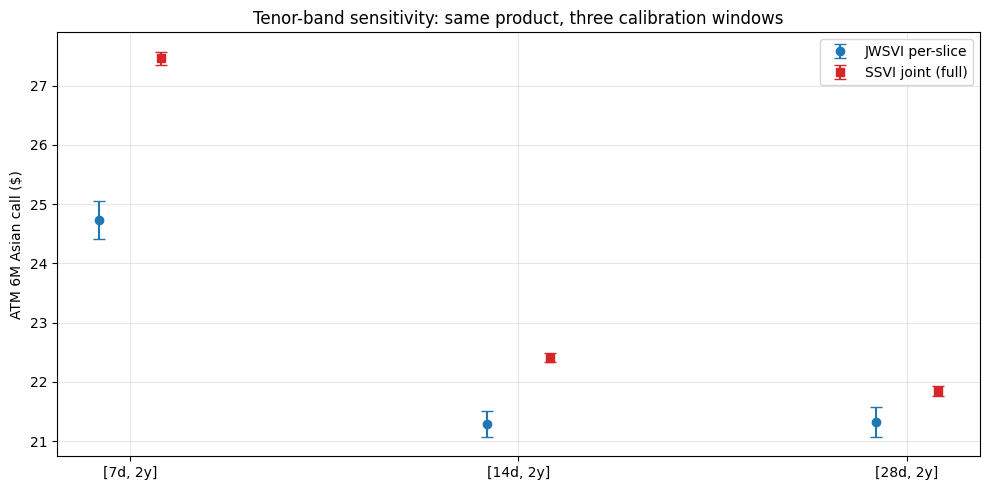

In [8]:
def _run_pipeline(min_dte_, max_dte_):
    """Build vol_data, pre-clean, calibrate both surfaces, price the same Asian."""
    vd = build_vol_grid('SPY', spot=spot, r=r, q=q, min_dte=min_dte_, max_dte=max_dte_)
    svi_raw = {
        e: (calibrate_svi(df['logMoneyness'].values,
                          df['impliedVolatility'].values, df['dcf'].iloc[0]),
            df['dcf'].iloc[0])
        for e, df in vd.items()
    }
    svi_clean, _ = filter_butterfly_arbitrage(svi_raw, threshold=-0.05, verbose=False)
    vd_clean = {k: vd[k] for k in svi_clean}
    if len(vd_clean) < 2:
        return None
    jw_slices = {k: (svi.to_jwsvi(d), d) for k, (svi, d) in svi_clean.items()}
    jw_surf = JWSVIVolSurface(jw_slices, spot=spot, r=r, q=q)
    ss_surf = calibrate_ssvi(vd_clean, spot=spot, r=r, q=q, mode='full', verbose=False)
    jw_lv, ss_lv = DupireLocalVol(jw_surf), DupireLocalVol(ss_surf)

    p_jw = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                          vol_surface=jw_surf, local_vol_surface=jw_lv)
    p_ss = AsianMCPricer(S0=spot, r=r, T=T, n_obs=n_obs,
                          vol_surface=ss_surf, local_vol_surface=ss_lv)
    np.random.seed(42); r_jw = p_jw.price_asian(K, 100_000)
    np.random.seed(42); r_ss = p_ss.price_asian(K, 100_000)

    K_chk = np.linspace(spot * 0.8, spot * 1.2, 80)
    _, jw_cal, _ = check_calendar_arbitrage(jw_surf, K_chk)
    _, ss_cal, _ = check_calendar_arbitrage(ss_surf, K_chk)

    return {
        'n_slices': len(vd_clean),
        'jw_price': r_jw['price'], 'jw_se': r_jw['std_err'],
        'ss_price': r_ss['price'], 'ss_se': r_ss['std_err'],
        'jw_cal': jw_cal, 'ss_cal': ss_cal,
    }


bands = [
    (7,  365 * 2, '[7d, 2y]   (wide, includes weeklies)'),
    (14, 365 * 2, '[14d, 2y]  (base case — used in §1-§6)'),
    (28, 365 * 2, '[28d, 2y]  (tighter case)')
]

results = []
for mn, mx, label in bands:
    print(f'Running {label}...')
    res = _run_pipeline(mn, mx)
    if res is None:
        print(f'  -> skipped (fewer than 2 surviving slices)')
        continue
    res['label'] = label
    results.append(res)

print()
header = (f'{"Tenor band":<40s} {"slices":>7s} {"JW price":>10s} {"JW SE":>9s} '
          f'{"SSVI price":>11s} {"SSVI SE":>9s} {"diff":>8s} '
          f'{"JW calArb":>10s} {"SSVI calArb":>12s}')
print(header)
print('-' * len(header))
for r_ in results:
    diff = r_['ss_price'] - r_['jw_price']
    print(f'{r_["label"]:<40s} {r_["n_slices"]:>7d} '
          f'${r_["jw_price"]:>9.2f} ${r_["jw_se"]:>8.4f} '
          f'${r_["ss_price"]:>10.2f} ${r_["ss_se"]:>8.4f} '
          f'${diff:>+7.2f} {r_["jw_cal"]:>10d} {r_["ss_cal"]:>12d}')

# Visual summary
labels = [r_['label'].split('  ')[0] for r_ in results]
jw_p = [r_['jw_price'] for r_ in results]
ss_p = [r_['ss_price'] for r_ in results]
jw_se = [r_['jw_se'] for r_ in results]
ss_se = [r_['ss_se'] for r_ in results]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
ax.errorbar(x - 0.08, jw_p, yerr=[1.96 * s for s in jw_se], fmt='o', capsize=4,
            color='tab:blue', label='JWSVI per-slice')
ax.errorbar(x + 0.08, ss_p, yerr=[1.96 * s for s in ss_se], fmt='s', capsize=4,
            color='tab:red', label='SSVI joint (full)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('ATM 6M Asian call ($)')
ax.set_title('Tenor-band sensitivity: same product, three calibration windows')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


**Reading the chart**:
- CIs **overlap** → calibrator choice doesn't matter, you have a price.
- CIs **don't overlap** → tighten the band or pull on a less-stale snapshot.
